# Adaptive tree: random grains, interactions and CUDA evaluation

This notebook first constructs geometry and connectivity only, then builds reusable numerical plans after inspecting the trees. The default geometry is a reproducible Voronoi-style grain structure: base cubes intersecting grain boundaries are recursively refined, and each final cube contributes one point dipole at its centre. Finite-cuboid kernels are not used.

The library prerequisites are AdaptiveTree, shared static topology, cross-level M2L and component diagnostics. CUDA benchmark cells require a working CUDA build and driver. Geometry cells remain usable without CUDA; select CPU explicitly for a smaller smoke run.


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cdfmm
try:
    from adaptive_showcase import *
except ModuleNotFoundError:
    from examples.notebooks.adaptive_showcase import *

# Geometry mode used by this notebook. The legacy locally refined material
# generator remains available as material_subdivision for comparisons.
GEOMETRY_MODE = "random_grains"
N_GRAINS = 5
BASE_GRID = 5
N_REFINE = 4
SEED = 42
N_PARTICLES = 15_000  # used only by the optional material_subdivision mode

LEAF_CAPACITY = 32
MAX_DEPTH = 4
BACKEND = cdfmm.ExecutionBackend.CUDA_FULL
ORDER = 6
N_EVALUATIONS = 10
SELECTED_LEAF = None
INCLUDE_ANCESTORS = True
RUN_BENCHMARK = True


## 1. Generate a reproducible random grain geometry

The default random_grains option starts from a 5 × 5 × 5 grid and places five seeded random grain centres in the domain. A cube is split into eight children when its eight corners belong to more than one nearest grain; this is repeated at most N_REFINE times beyond the base grid. Cubes fully inside one grain remain coarse. Each final cube contains one dipole at its centre, with moment m_i = V_i M_i. Grain magnetisation is inherited by descendants, so refinement conserves volume and total moment.

Set GEOMETRY_MODE = material_subdivision to use the earlier target-particle material generator instead.


Geometry: random_grains; dipoles: 63,433; base grid: 5^3; maximum material refinement: 4
Volume: 1.0000000000000004 total moment: [-0.14265692  0.27633558  0.22458252]


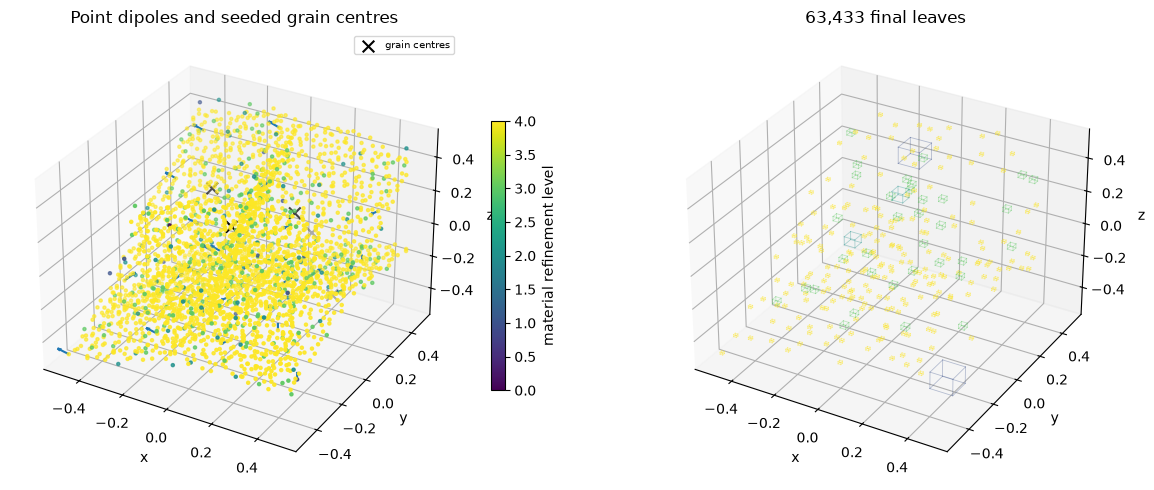

In [2]:
if GEOMETRY_MODE == "random_grains":
    material = generate_random_grains(N_GRAINS, BASE_GRID, N_REFINE, SEED)
elif GEOMETRY_MODE == "material_subdivision":
    material = generate_material(N_PARTICLES, SEED, BASE_GRID)
else:
    raise ValueError(f"unknown GEOMETRY_MODE: {GEOMETRY_MODE!r}")

positions = material["positions"]
material_levels = material["material_levels"]
print(f"Geometry: {GEOMETRY_MODE}; dipoles: {len(positions):,}; "
      f"base grid: {BASE_GRID}^3; maximum material refinement: {material_levels.max(initial=0)}")
print("Volume:", np.sum(material["sides"]**3), "total moment:", material["moments"].sum(axis=0))

fig = plt.figure(figsize=(13, 5))
axis = fig.add_subplot(121, projection="3d")
sample = np.linspace(0, len(positions)-1, min(3000, len(positions)), dtype=int)
scatter = axis.scatter(*positions[sample].T, c=material_levels[sample], s=5, cmap="viridis")
fig.colorbar(scatter, ax=axis, label="material refinement level", shrink=.6)
arrows = sample[::max(1, len(sample)//25)]
axis.quiver(*positions[arrows].T, *material["magnetisations"][arrows].T, length=.06, normalize=True)
if "grain_centres" in material:
    axis.scatter(*material["grain_centres"].T, marker="x", s=70, c="black", linewidths=1.5,
                 label="grain centres")
    axis.legend(fontsize=7)
finish_3d_axes(axis, "Point dipoles and seeded grain centres")

axis = fig.add_subplot(122, projection="3d")
cmap = plt.get_cmap("viridis")
normalise = plt.Normalize(vmin=0, vmax=max(1, int(material_levels.max(initial=0))))
cube_sample = sample[::max(1, len(sample)//250)]
for i in cube_sample:
    draw_box_3d(axis, positions[i], material["sides"][i]/2,
                colour=cmap(normalise(material_levels[i])), alpha=.35, linewidth=.6)
finish_3d_axes(axis, "Final grain cubes (colour = refinement level)")
axis.set_title(f"{len(positions):,} final leaves")
fig.tight_layout()


## 2. Build and inspect trees without operators

The uniform tree uses the adaptive tree's **reached depth**, with identical root bounds. Leaf capacity is a splitting trigger, not a guarantee at the depth cap: at depth 3, at most 512 leaves cannot hold 15,000 particles at capacity 10.

Topology positions are normalised to the unit root; `coordinate_origin` and `coordinate_scale` map them back to physical coordinates. No multipoles, translation matrices or GPU plans exist yet.


,nodes,leaves,reached_depth,leaves_by_level,occupancy_min,occupancy_median,occupancy_max,depth_limited,m2l,cross_level_m2l,p2p_pairs,topology_bytes
adaptive,1883,1634,4,"{2: 17, 3: 166, 4: 1451}",1,33.0,118,13,143528,8704,75271901,33940040
uniform,4681,2320,4,{4: 2320},1,11.0,118,8,276060,0,56225173,59621344


adaptive                 0.052058
uniform                  0.052231
adaptive_tree            0.017981
adaptive_interactions    0.026558
uniform_tree             0.024321
uniform_topology         0.027910
Name: seconds, dtype: float64

interactions
method   source_level target_level              
uniform  4            4                   231240
adaptive 4            4                   104240
uniform  3            3                    41724
adaptive 3            3                    27488
         2            2                     3096
uniform  2            2                     3096
adaptive 3            4                     2691
         4            3                     2691
         2            4                     1356
         4            2                     1356
         2            3                      305
         3            2                      305

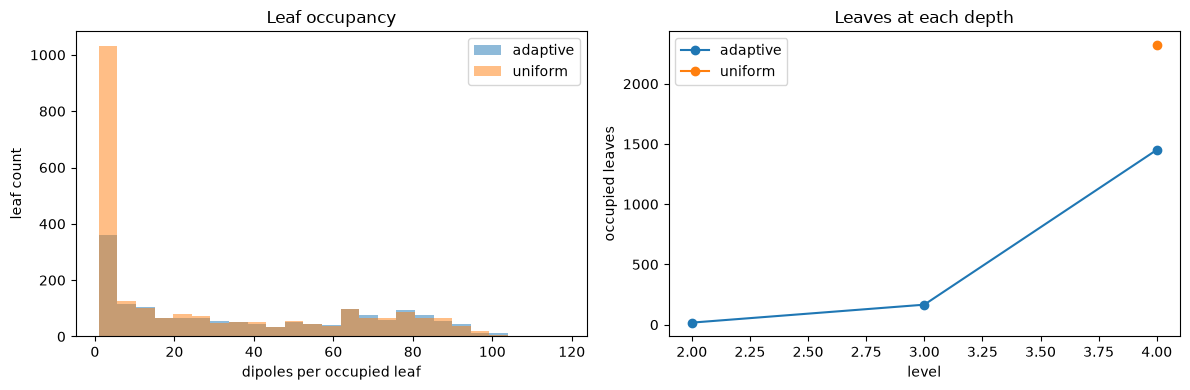

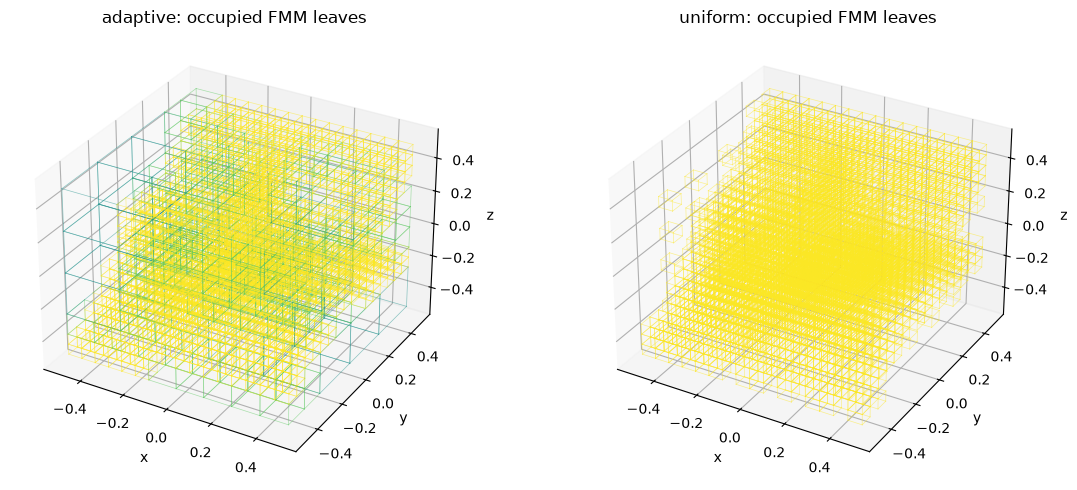

In [3]:
adaptive_tree, uniform_tree, topologies, tree_times = build_trees(positions, LEAF_CAPACITY, MAX_DEPTH)
summaries = {name: summarise(t, LEAF_CAPACITY, MAX_DEPTH) for name, t in topologies.items()}
display(pd.DataFrame(summaries).T)
display(pd.Series(tree_times, name="seconds"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, t in topologies.items():
    axes[0].hist([leaf.count for leaf in t.source_leaves], bins=25, alpha=.5, label=name)
    counts = summaries[name]["leaves_by_level"]
    axes[1].plot(list(counts), list(counts.values()), "o-", label=name)
axes[0].set(xlabel="dipoles per occupied leaf", ylabel="leaf count", title="Leaf occupancy")
axes[1].set(xlabel="level", ylabel="occupied leaves", title="Leaves at each depth")
for axis in axes: axis.legend()
plt.tight_layout()
fig = plt.figure(figsize=(12, 5))
for panel, (name, topology) in enumerate(topologies.items(), 1):
    axis = fig.add_subplot(1, 2, panel, projection="3d")
    for leaf in topology.target_leaves:
        node = topology.nodes[leaf.node]
        draw_box_3d(axis, vec3_to_array(node.centre), node.half_width,
                    colour=plt.cm.viridis(node.level / max(1, MAX_DEPTH)), alpha=.5, linewidth=.5)
    finish_3d_axes(axis, f"{name}: occupied FMM leaves")
plt.tight_layout()
level_pairs = []
for name, topology in topologies.items():
    for interaction in topology.m2l_interactions:
        level_pairs.append((name, interaction.source_level, interaction.target_level))
if level_pairs:
    display(pd.DataFrame(level_pairs, columns=["method", "source_level", "target_level"])
            .value_counts().rename("interactions").to_frame())


## 3. Compare actual interaction records

Same-level M2L retains the classical list2 partition. Unequal boxes use non-touching bounding boxes and the enclosing-sphere criterion $(r_s+r_t)/d\leq0.75$. This replaces the originally proposed twice-larger-width rule, which suppressed cross-level M2L in this traversal.

Blue/cyan mark same/unequal-level P2P; orange/purple mark same/cross-level M2L. The ancestor toggle includes contributions inherited by L2L. Counts describe execution records, not a reconstructed drawing stencil. Empty categories are shown explicitly.


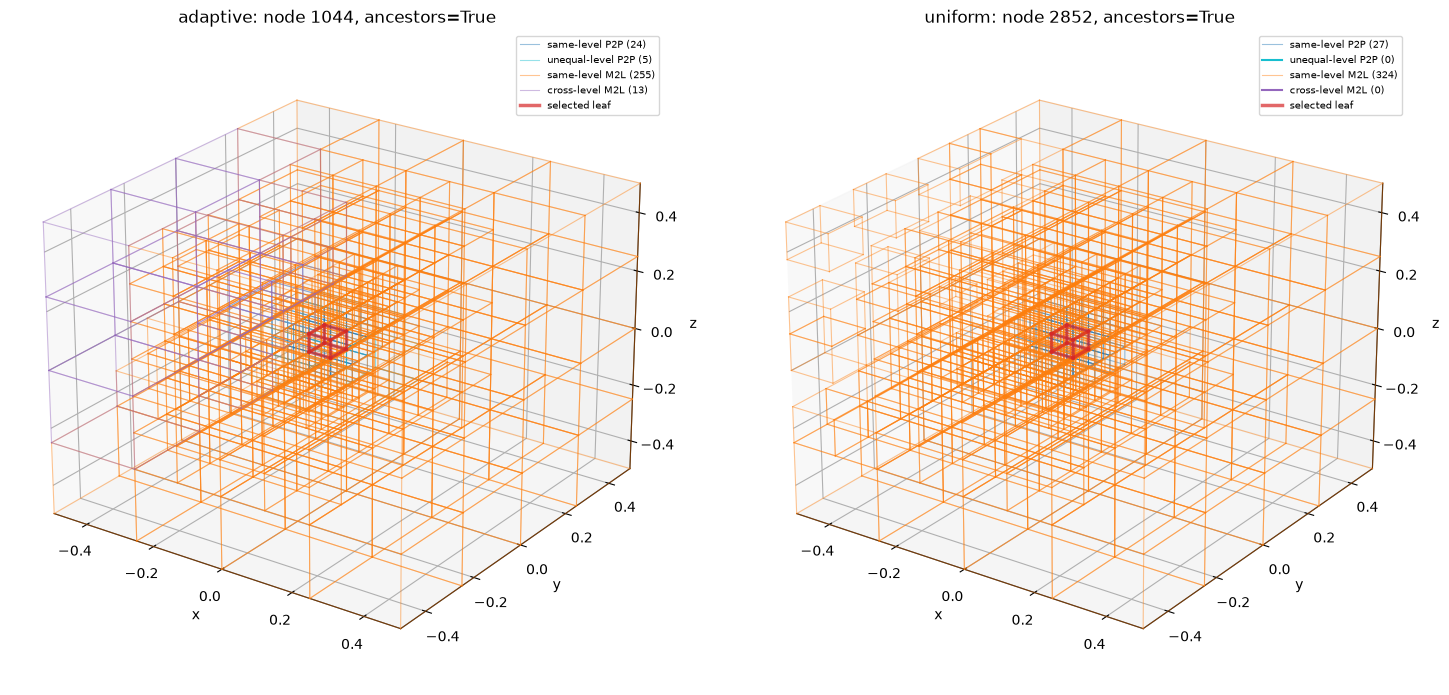

interactive(children=(Dropdown(description='selected_leaf', index=807, options=(4, 5, 6, 7, 8, 9, 10, 11, 13, …

In [4]:
selected = select_leaf(topologies["adaptive"]) if SELECTED_LEAF is None else SELECTED_LEAF

def plot_comparison(selected_leaf=selected, include_ancestors=INCLUDE_ANCESTORS):
    adaptive_node = topologies["adaptive"].nodes[selected_leaf]
    uniform_id = matching_node(topologies["uniform"], adaptive_node)
    fig = plt.figure(figsize=(15, 7))
    for panel, name, node_id in [(1, "adaptive", selected_leaf), (2, "uniform", uniform_id)]:
        axis = fig.add_subplot(1, 2, panel, projection="3d")
        draw_interactions(axis, topologies[name], node_id, include_ancestors)
        axis.set_title(f"{name}: node {node_id}, ancestors={include_ancestors}")
    plt.tight_layout()
    plt.show()

plot_comparison()
try:
    import ipywidgets as widgets
    choices = [leaf.node for leaf in topologies["adaptive"].target_leaves
               if topologies["adaptive"].nodes[leaf.node].level == adaptive_tree.topology.maximum_level]
    widgets.interact(plot_comparison, selected_leaf=widgets.Dropdown(options=choices, value=selected),
                     include_ancestors=widgets.Checkbox(value=INCLUDE_ANCESTORS))
except ImportError:
    print("ipywidgets unavailable; change SELECTED_LEAF and INCLUDE_ANCESTORS above.")


## 4. Construct static plans, then evaluate ten moment states

This is the first operator-allocation cell. Defaults are spherical order 6, FP64, `CUDA_FULL`, and reduced/signed Tensor6 P2P with fixed self identities. Both methods receive the same moment states. Each plan is built once and warmed up once; timed calls return synchronised host fields.

Persistent caches are disabled for prebuilt topology until adaptive cache identity validation is implemented. GPU unavailability does not trigger a silent CPU substitution. For a CPU smoke run, explicitly select `CPU_STATIC`, a few hundred particles and order 3–4.


,method,run,seconds
0,adaptive,0,0.009884
1,adaptive,1,0.009710
2,adaptive,2,0.009891
3,adaptive,3,0.010114
4,adaptive,4,0.009706
5,adaptive,5,0.009800
6,adaptive,6,0.009757
7,adaptive,7,0.009964
8,adaptive,8,0.009768
9,adaptive,9,0.010083


,median,min,max
method,,,
adaptive,0.009842,0.009706,0.010114
uniform,0.003870,0.003735,0.004126


,method,tree_seconds,numerical_plan_seconds,total_setup_seconds,backend_packing_seconds,cuda_upload_seconds,retained_bytes,device_bytes
0,adaptive,0.052058,25.577564,25.629622,0.0,0.370747,12700064925,834161736
1,uniform,0.052231,12.596241,12.648472,0.0,0.239915,9570028757,566924568


,method,run,moment_permutation,multipole_reset,p2m,m2m,local_reset,m2l,m2l_scale,m2l_gather,...,cuda_kernel,cuda_d2h,cuda_m2l_h2d,cuda_m2l_d2h,cuda_p2p_h2d,cuda_p2p_kernel,cuda_p2p_d2h,cuda_p2p_wait,total,evaluations
0,adaptive,0,0.0,0.0,0.000076,0.001288,0.0,0.001523,0.000006,0.0,...,0.012063,0.000065,0.0,0.0,0.0,0.009021,0.0,0.0,0.009578,1
1,adaptive,1,0.0,0.0,0.000076,0.001294,0.0,0.001399,0.000006,0.0,...,0.011811,0.000070,0.0,0.0,0.0,0.008889,0.0,0.0,0.009430,1
2,adaptive,2,0.0,0.0,0.000076,0.001290,0.0,0.001567,0.000006,0.0,...,0.012158,0.000072,0.0,0.0,0.0,0.009070,0.0,0.0,0.009608,1
3,adaptive,3,0.0,0.0,0.000076,0.001288,0.0,0.001608,0.000006,0.0,...,0.012436,0.000067,0.0,0.0,0.0,0.009309,0.0,0.0,0.009841,1
4,adaptive,4,0.0,0.0,0.000076,0.001286,0.0,0.001779,0.000006,0.0,...,0.012194,0.000066,0.0,0.0,0.0,0.008899,0.0,0.0,0.009430,1
5,adaptive,5,0.0,0.0,0.000076,0.001298,0.0,0.001457,0.000006,0.0,...,0.011953,0.000063,0.0,0.0,0.0,0.008966,0.0,0.0,0.009496,1
6,adaptive,6,0.0,0.0,0.000076,0.001294,0.0,0.001443,0.000008,0.0,...,0.011869,0.000065,0.0,0.0,0.0,0.008899,0.0,0.0,0.009440,1
7,adaptive,7,0.0,0.0,0.001294,0.000127,0.0,0.001481,0.000006,0.0,...,0.012207,0.000064,0.0,0.0,0.0,0.009149,0.0,0.0,0.009671,1
8,adaptive,8,0.0,0.0,0.000076,0.001290,0.0,0.001563,0.000006,0.0,...,0.012033,0.000064,0.0,0.0,0.0,0.008949,0.0,0.0,0.009477,1
9,adaptive,9,0.0,0.0,0.000076,0.001292,0.0,0.001438,0.000006,0.0,...,0.012219,0.000069,0.0,0.0,0.0,0.009258,0.0,0.0,0.009798,1


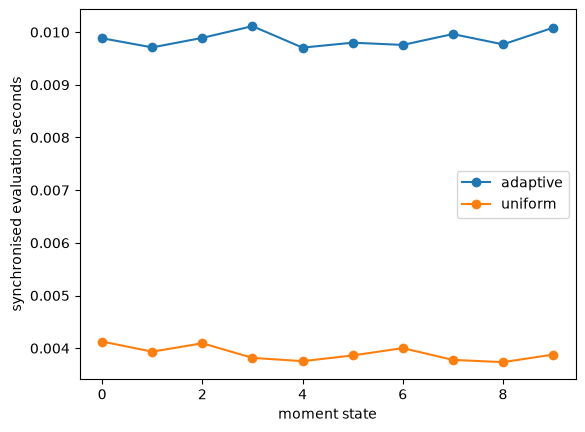

In [5]:
can_benchmark = RUN_BENCHMARK and (BACKEND != cdfmm.ExecutionBackend.CUDA_FULL or cdfmm.cuda_full_available())
if not can_benchmark:
    print("Numerical cells skipped: enable RUN_BENCHMARK and a working CUDA device, or explicitly choose CPU_STATIC.")
else:
    states = moment_states(material, N_EVALUATIONS, SEED + 1)
    options = make_options(len(positions), BACKEND, ORDER)
    plans, plan_setup, measurements, fields = benchmark(topologies, states, options)
    timing_table = pd.DataFrame([{k:v for k,v in row.items() if k != "phases"} for row in measurements])
    display(timing_table)
    display(timing_table.groupby("method")["seconds"].agg(["median", "min", "max"]))
    setup_rows = []
    for name, plan in plans.items():
        stats = dict(plan.static_plan_statistics)
        setup_rows.append(dict(method=name, tree_seconds=tree_times[name],
                               numerical_plan_seconds=plan_setup[name],
                               total_setup_seconds=tree_times[name] + plan_setup[name],
                               backend_packing_seconds=stats["backend_packing_seconds"],
                               cuda_upload_seconds=stats["cuda_upload_seconds"],
                               retained_bytes=stats["total_persistent_bytes"],
                               device_bytes=plan.cuda_plan_statistics["persistent_device_bytes"] if hasattr(plan, "cuda_plan_statistics") else None))
    display(pd.DataFrame(setup_rows))
    display(pd.DataFrame([dict(method=row["method"], run=row["run"], **row["phases"]) for row in measurements]))
    for name in plans:
        rows = timing_table[timing_table.method == name]
        plt.plot(rows.run, rows.seconds, "o-", label=name)
    plt.xlabel("moment state"); plt.ylabel("synchronised evaluation seconds"); plt.legend(); plt.show()


CUDA far and near work can overlap: phase times are diagnostic measurements and need not add to wall time. Setup time includes operator construction, backend packing and uploads; the tree timings above were measured independently. No topology rebuild occurs during evaluation.

## 5. Accuracy and separate far/P2P fields

Direct references are computed outside the benchmark for the first and last states. `CudaDirectPlan` evaluates point pairs without retaining a dense $N^2$ tensor. Self identities match the FMM.

Adaptive and uniform near/far components need not agree individually because their partitions differ. Each P2P field is therefore checked against its own explicit leaf-pair direct sum, and its far field against total direct minus that near reference.


,method,run,relative_l2,absolute_rms,absolute_max
0,adaptive,0,0.004744,0.002033,0.059674
1,uniform,0,0.006138,0.002630,0.123886
2,adaptive versus uniform,0,0.006519,0.002793,0.122483
3,adaptive,9,0.004601,0.002316,0.063087
4,uniform,9,0.005505,0.002771,0.110334
5,adaptive versus uniform,9,0.005739,0.002889,0.130439


,method,run,component,field_norm,relative_l2,absolute_rms,absolute_max
0,adaptive,0,H_p2p,85.048214,1.127423e-15,3.807100e-16,3.503035e-15
1,adaptive,0,H_far,56.575020,9.049648e-03,2.032622e-03,5.967416e-02
2,uniform,0,H_p2p,74.054080,1.058237e-15,3.111532e-16,1.686530e-15
3,uniform,0,H_far,65.804423,1.006671e-02,2.629691e-03,1.238862e-01
4,adaptive,9,H_p2p,90.796745,1.124407e-15,4.053556e-16,4.121867e-15
5,adaptive,9,H_far,73.674850,7.917124e-03,2.315976e-03,6.308655e-02
6,uniform,9,H_p2p,81.424914,1.006243e-15,3.253138e-16,2.221833e-15
7,uniform,9,H_far,82.651744,8.444494e-03,2.770819e-03,1.103338e-01


,component,difference_norm
0,H_far,42.709746
1,H_p2p,42.692771
2,H_total,0.703506


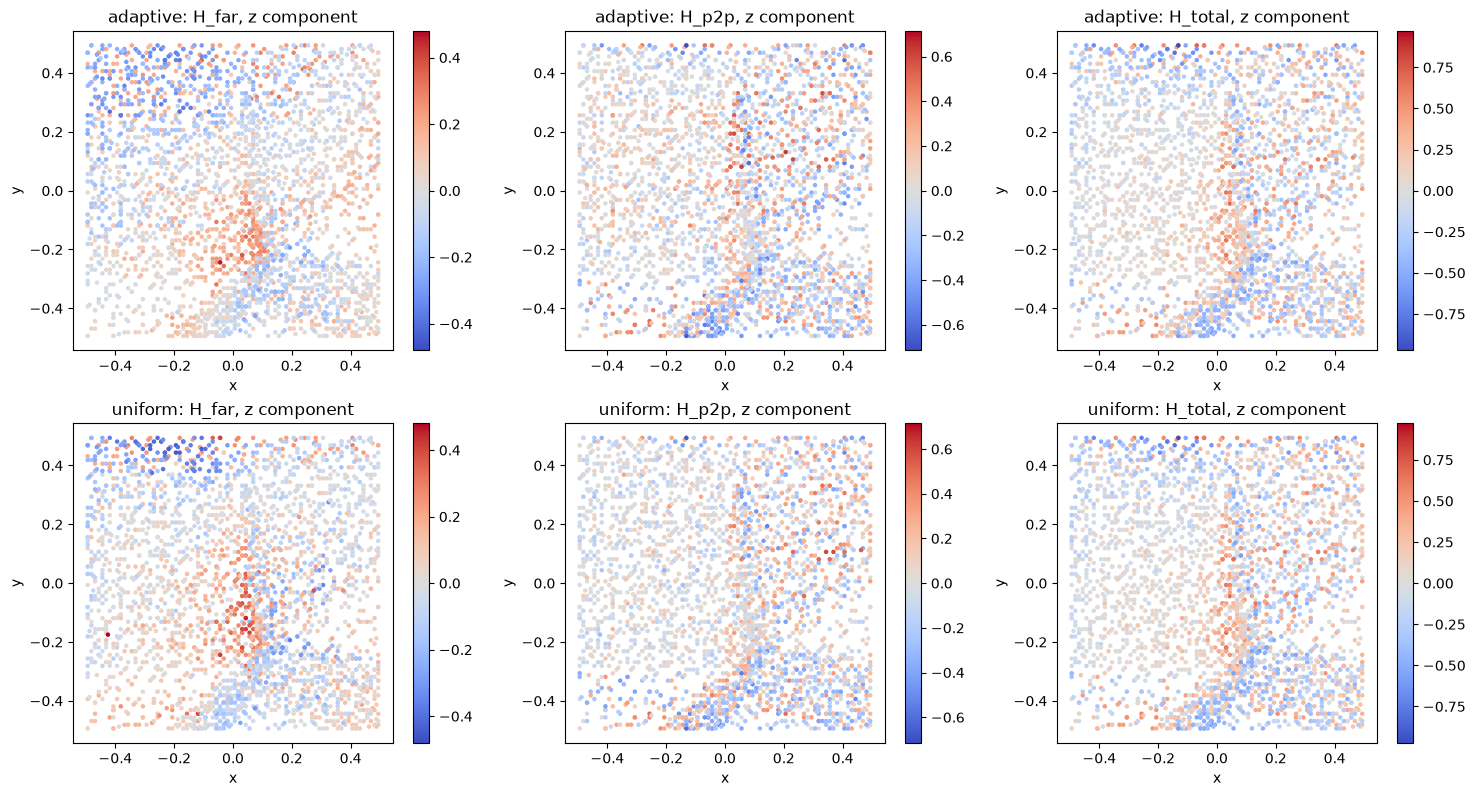

In [6]:
if can_benchmark:
    references = {run: direct_field(positions, states[run], BACKEND == cdfmm.ExecutionBackend.CUDA_FULL)
                  for run in sorted({0, len(states)-1})}
    accuracy_rows, component_rows = [], []
    components = {}
    for run, reference in references.items():
        for name, plan in plans.items():
            accuracy_rows.append(dict(method=name, run=run, **field_errors(fields[name][run], reference)))
            parts = plan.evaluate_components(states[run])  # Diagnostic copies outside timing.
            near_reference = direct_near(topologies[name], positions, states[run])
            components[name, run] = parts
            scale = max(np.linalg.norm(parts["H_total"]), 1e-30)
            assert np.linalg.norm(parts["H_far"] + parts["H_p2p"] - parts["H_total"]) <= 1e-12 * scale
            for key, truth in [("H_p2p", near_reference), ("H_far", reference - near_reference)]:
                component_rows.append(dict(method=name, run=run, component=key,
                                           field_norm=np.linalg.norm(parts[key]), **field_errors(parts[key], truth)))
        accuracy_rows.append(dict(method="adaptive versus uniform", run=run,
                                  **field_errors(fields["adaptive"][run], fields["uniform"][run])))
    display(pd.DataFrame(accuracy_rows))
    display(pd.DataFrame(component_rows))
    display(pd.DataFrame([dict(component=key, difference_norm=np.linalg.norm(
        components["adaptive", 0][key] - components["uniform", 0][key]))
        for key in ["H_far", "H_p2p", "H_total"]]))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    sample = np.linspace(0, len(positions)-1, min(3000, len(positions)), dtype=int)
    for col, key in enumerate(["H_far", "H_p2p", "H_total"]):
        limit = max(np.max(np.abs(components[name, 0][key][sample, 2])) for name in plans)
        for row, name in enumerate(plans):
            scatter = axes[row, col].scatter(positions[sample, 0], positions[sample, 1],
                c=components[name, 0][key][sample, 2], s=5, cmap="coolwarm", vmin=-limit, vmax=limit)
            axes[row, col].set(title=f"{name}: {key}, z component", xlabel="x", ylabel="y", aspect="equal")
            fig.colorbar(scatter, ax=axes[row, col])
    plt.tight_layout(); plt.show()


## Interpretation

- Capacity-limited and depth-limited leaves are different stop conditions.
- A shallower adaptive tree is not guaranteed to be faster: compare actual P2P work and setup memory.
- Non-zero component differences are expected; assess total accuracy against direct summation.
- Changing capacity rebuilds topology; changing moments reuses the static geometry plan.
- The figures show point-dipole physics. Finite magnetised-cuboid evaluation is a separate experiment.
